<a href="https://colab.research.google.com/github/sandanila/weather-prediction/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [75]:
data = pd.read_csv('/content/Project 1 - Weather Dataset.csv')

In [76]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [77]:
data.shape

(8784, 8)

In [78]:
data.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


In [80]:
#find outliner
numeric_data = data.select_dtypes(include=['number'])

q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
iqr = q3 - q1
ub = q3 + 1.5 * iqr
lb = q1 - 1.5 * iqr

cleandata = numeric_data[~((numeric_data < lb) | (numeric_data > ub)).any(axis=1)]

In [81]:
cleandata.shape

(5069, 6)

In [105]:
colnames=['Temp_C',	'Dew Point Temp_C',	'Rel Hum_%',	'Wind Speed_km/h',	'Visibility_km']
scaler = StandardScaler()
for i in colnames:
  cleandata.loc[:, i] = scaler.fit_transform(cleandata[[i]])

In [56]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-0.906815,-0.593184,1.097553,-1.259808,-1.557954,101.24,Fog
1,1/1/2012 1:00,-0.906815,-0.574805,1.156662,-1.259808,-1.557954,101.24,Fog
2,1/1/2012 2:00,-0.906815,-0.547238,1.274879,-0.914513,-1.874862,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-0.881146,-0.528860,1.215770,-1.029611,-1.874862,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-0.881146,-0.538049,1.215770,-0.914513,-1.811480,101.23,Fog


In [59]:
data.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8.784000e+03,8.784000e+03,8.784000e+03,8.784000e+03,8.784000e+03,8784.000000
mean,-5.176996e-17,-3.882747e-17,-2.588498e-17,-3.559185e-17,-6.471245e-17,101.051623
std,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,0.844005
min,-2.746432e+00,-2.853704e+00,-2.921854e+00,-1.720203e+00,-2.175924e+00,97.520000
25%,-7.442442e-01,-7.769658e-01,-6.757152e-01,-6.843153e-01,-2.824002e-01,100.560000
50%,4.294056e-02,6.843184e-02,3.359196e-02,-2.239208e-01,-2.110960e-01,101.070000
75%,8.557944e-01,8.495058e-01,8.020080e-01,5.817695e-01,-2.110960e-01,101.590000
max,2.070797e+00,2.007333e+00,1.925078e+00,7.832983e+00,1.634892e+00,103.650000


In [87]:
x=cleandata.iloc[:,0:-1]
y=cleandata.iloc[:,-1]

In [88]:
y.shape

(5069,)

In [94]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [101]:
xtrain.shape

(4055, 5)

In [102]:
model = LinearRegression()

In [103]:
model.fit(xtrain,ytrain)

LinearRegression()

In [107]:
ypred=model.predict(xtest)

In [108]:
ytest.head()

,Press_kPa
1953,101.53
5150,100.44
5851,100.52
332,101.62
4340,99.51


In [109]:
ypred

array([100.64019136, 100.74178076, 100.76432599, ..., 101.30942956,
       100.42031578, 100.78706796])

In [110]:
mae=mean_absolute_error(ytest,ypred)
mse=mean_squared_error(ytest,ypred)
rmse=root_mean_squared_error(ytest,ypred)
r2sc=r2_score(ytest,ypred)

In [113]:
print(f"MAE      = {mae}")
print(f"MSE      = {mse}")
print(f"RMSE     = {rmse}")
print(f"r2 score = {r2sc}")

MAE      = 0.5045304851057981
MSE      = 0.41488095918612494
RMSE     = 0.6441125361193686
r2 score = 0.2785554701566094


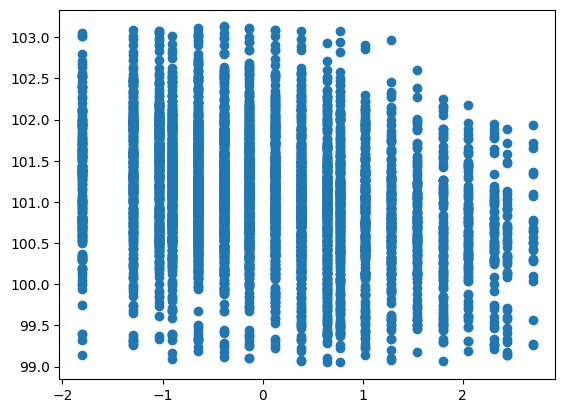

In [129]:
plt.figure()
plt.scatter(cleandata['Wind Speed_km/h'],y)
plt.show()